# Assessment | Full ML Pipeline: From Clustering to Deployment

---
### Task 1 — Unsupervised Exploration

1. Load the Palmer Penguins dataset (`sns.load_dataset("penguins")`).
2. Clean the data: handle missing values, examine distributions, and note any anomalies.
3. Select the numeric features and scale them with `StandardScaler`.
4. Apply **PCA** (2 components) and **t-SNE** (2 components, `random_state=42`). Create a side-by-side plot colored by actual species.
5. Apply **K-Means** (k=3) and **DBSCAN** (experiment with at least 2 `eps`/`min_samples` combos) to the scaled data.
6. Evaluate each clustering result with the **silhouette score**.
7. Compare your best clustering labels to the actual species using **adjusted Rand score** and **normalized mutual information**. Visualize the comparison on a PCA projection.
8. In a markdown cell, summarize: How well did unsupervised methods recover the species structure? Where did they fail?

### Step 1.1 — Import Libraries & Load Data

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

In [26]:
# Load the Palmer Penguins dataset
df = sns.load_dataset('penguins')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


### Step 1.2 — Data Cleaning & Exploration

In [27]:
# Check data types and missing values
print("=" * 50)
print("DATA INFO")
print("=" * 50)
print(df.info())
print("\n")
print("=" * 50)
print("MISSING VALUES")
print("=" * 50)
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print(f"Rows with missing values: {df.isnull().any(axis=1).sum()} out of {len(df)}")

DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB
None


MISSING VALUES
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Total missing values: 19
Rows with missing values: 11 out of 344


In [28]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [29]:
print("Species distribution:")
print(df['species'].value_counts())
print("\nIsland distribution:")
print(df['island'].value_counts())
print("\nSex distribution:")
print(df['sex'].value_counts(dropna=False))

Species distribution:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Island distribution:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

Sex distribution:
sex
Male      168
Female    165
NaN        11
Name: count, dtype: int64


Numeric columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


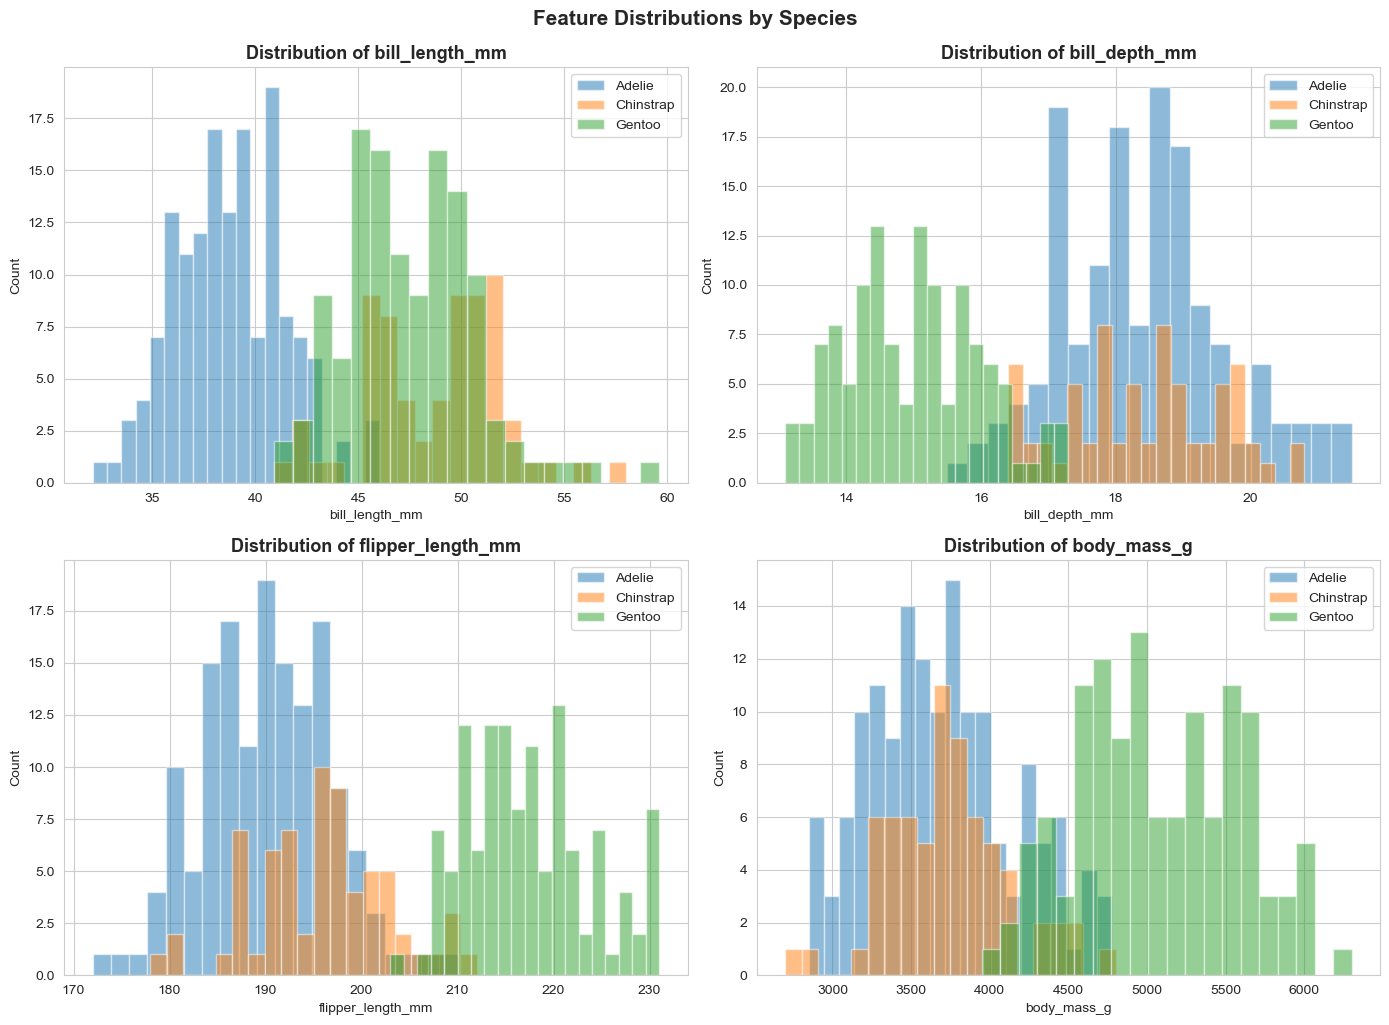

In [30]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(numeric_cols):
    ax = axes[i // 2, i % 2]
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        ax.hist(subset[col].dropna(), alpha=0.5, label=species, bins=20)
    ax.set_title(f'Distribution of {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.suptitle('Feature Distributions by Species', fontsize=15, fontweight='bold', y=1.02)
plt.show()

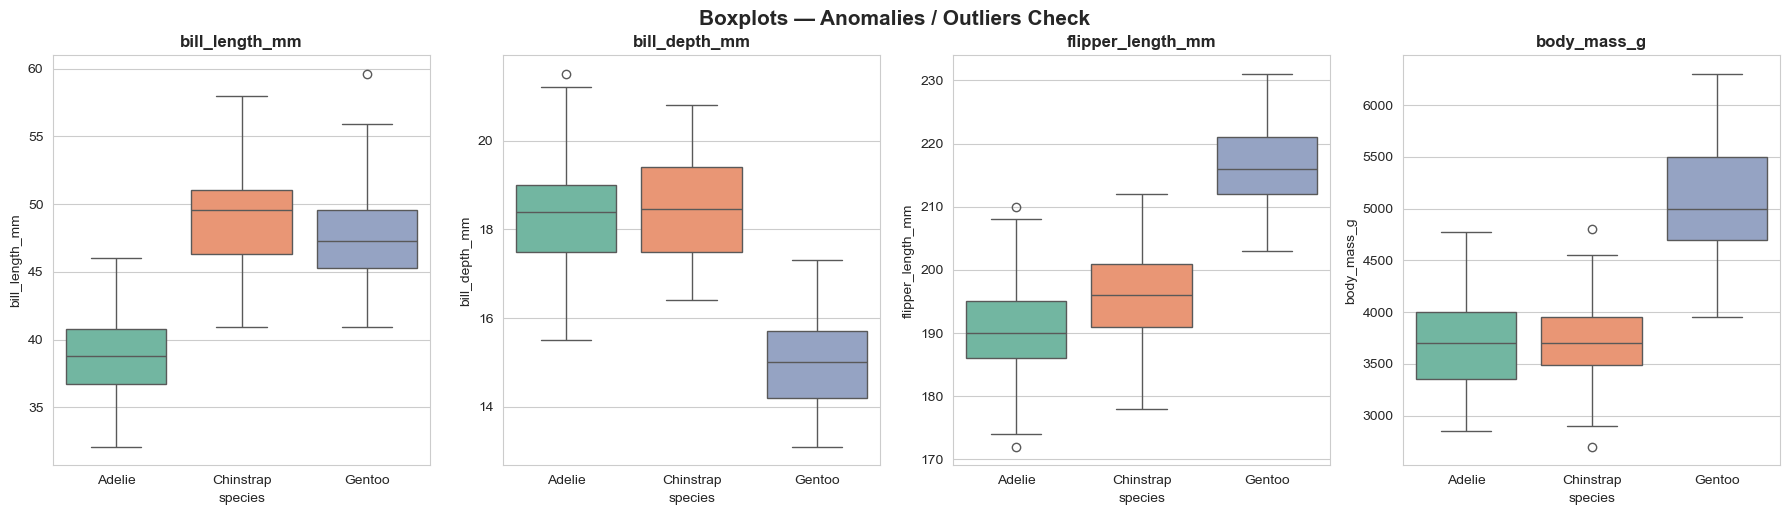

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='species', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.suptitle('Boxplots — Anomalies / Outliers Check', fontsize=15, fontweight='bold', y=1.02)
plt.show()

In [32]:
df_clean = df.dropna().reset_index(drop=True)
print(f"Shape after dropping missing values: {df_clean.shape}")
print(f"Dropped {len(df) - len(df_clean)} rows")

Shape after dropping missing values: (333, 7)
Dropped 11 rows


### Step 1.3 — Feature Scaling

In [33]:
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric features for clustering: {numeric_features}")

X_numeric = df_clean[numeric_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

print(f"\nScaled data shape: {X_scaled.shape}")
print(f"Mean after scaling (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std after scaling (should be ~1): {X_scaled.std(axis=0).round(4)}")

Numeric features for clustering: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

Scaled data shape: (333, 4)
Mean after scaling (should be ~0): [ 0.  0.  0. -0.]
Std after scaling (should be ~1): [1. 1. 1. 1.]


### Step 1.4 — PCA & t-SNE Dimensionality Reduction

In [34]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.4f} ({pca.explained_variance_ratio_.sum()*100:.1f}%)")

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

PCA explained variance ratio: [0.68633893 0.19452929]
Total variance explained: 0.8809 (88.1%)


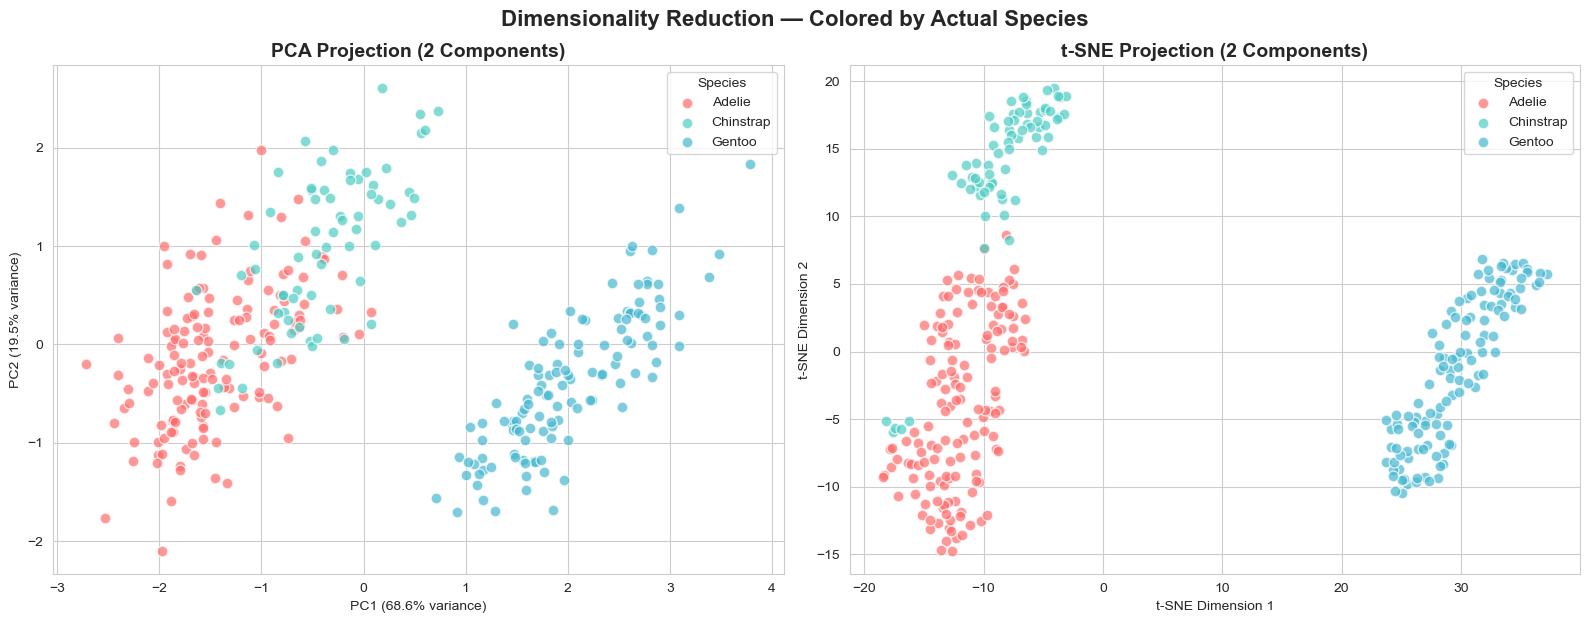

In [35]:
species_labels = df_clean['species']
colors = {'Adelie': '#FF6B6B', 'Chinstrap': '#4ECDC4', 'Gentoo': '#45B7D1'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for species in species_labels.unique():
    mask = species_labels == species
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[species], label=species, alpha=0.7, edgecolors='white', s=60)
axes[0].set_title('PCA Projection (2 Components)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend(title='Species')

for species in species_labels.unique():
    mask = species_labels == species
    axes[1].scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=colors[species], label=species, alpha=0.7, edgecolors='white', s=60)
axes[1].set_title('t-SNE Projection (2 Components)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].legend(title='Species')

plt.tight_layout()
plt.suptitle('Dimensionality Reduction — Colored by Actual Species', fontsize=16, fontweight='bold', y=1.03)
plt.show()

### Step 1.5 — Clustering: K-Means & DBSCAN

In [36]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
print("K-Means Results:")
print(f"  Cluster sizes: {np.bincount(kmeans_labels)}")
print(f"  Silhouette Score: {silhouette_score(X_scaled, kmeans_labels):.4f}")

K-Means Results:
  Cluster sizes: [129 119  85]
  Silhouette Score: 0.4462


In [37]:
dbscan_configs = [
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 0.8, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 10},
]
dbscan_results = {}
for config in dbscan_configs:
    dbscan = DBSCAN(eps=config['eps'], min_samples=config['min_samples'])
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    if n_clusters >= 2 and n_noise < len(labels):
        mask = labels != -1
        sil = silhouette_score(X_scaled[mask], labels[mask])
    else:
        sil = None
    config_key = f"eps={config['eps']}, min_samples={config['min_samples']}"
    dbscan_results[config_key] = {'labels': labels, 'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': sil}
    sil_str = f"{sil:.4f}" if sil is not None else "N/A"
    print(f"DBSCAN ({config_key}): {n_clusters} clusters, {n_noise} noise points, Silhouette: {sil_str}")

DBSCAN (eps=0.5, min_samples=5): 4 clusters, 66 noise points, Silhouette: 0.4223
DBSCAN (eps=0.8, min_samples=5): 2 clusters, 5 noise points, Silhouette: 0.5351
DBSCAN (eps=1.0, min_samples=10): 2 clusters, 1 noise points, Silhouette: 0.5329


### Step 1.6 — Clustering Evaluation (Silhouette Scores)

In [38]:
print("=" * 60)
print("SILHOUETTE SCORE COMPARISON")
print("=" * 60)
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
print(f"{'K-Means (k=3)':<45} | Silhouette: {kmeans_sil:.4f}")
for config_key, result in dbscan_results.items():
    sil_str = f"{result['silhouette']:.4f}" if result['silhouette'] is not None else 'N/A'
    print(f"DBSCAN ({config_key}){' ' * (30 - len(config_key))} | Silhouette: {sil_str}")

SILHOUETTE SCORE COMPARISON
K-Means (k=3)                                 | Silhouette: 0.4462
DBSCAN (eps=0.5, min_samples=5)         | Silhouette: 0.4223
DBSCAN (eps=0.8, min_samples=5)         | Silhouette: 0.5351
DBSCAN (eps=1.0, min_samples=10)        | Silhouette: 0.5329


### Step 1.7 — Comparison with Actual Species Labels

In [39]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
true_labels = le.fit_transform(species_labels)
print(f"Species mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")

all_results = {'K-Means (k=3)': {'labels': kmeans_labels, 'silhouette': kmeans_sil, 'n_noise': 0, 'n_clusters': 3}}
for config_key, result in dbscan_results.items():
    all_results[f'DBSCAN ({config_key})'] = result

print("\n" + "=" * 80)
print("COMPARISON WITH ACTUAL SPECIES")
print("=" * 80)

best_method = None
best_ari = -1
for method_name, result in all_results.items():
    labels = result['labels']
    n_noise = result.get('n_noise', 0)
    n_clusters = result.get('n_clusters', len(set(labels)))
    coverage = ((labels != -1).sum() / len(labels)) * 100
    ari = adjusted_rand_score(true_labels, labels)
    nmi = normalized_mutual_info_score(true_labels, labels)
    print(f"{method_name}:")
    print(f"  Clusters found: {n_clusters} | Noise points: {n_noise} | Coverage: {coverage:.1f}%")
    print(f"  Adjusted Rand Index (ARI): {ari:.4f}")
    print(f"  Normalized Mutual Information (NMI): {nmi:.4f}\n")
    if ari > best_ari:
        best_ari = ari
        best_method = method_name
        best_labels = labels
print(f">>> Best clustering method: {best_method} (ARI = {best_ari:.4f})")

Species mapping: {'Adelie': np.int64(0), 'Chinstrap': np.int64(1), 'Gentoo': np.int64(2)}

COMPARISON WITH ACTUAL SPECIES
K-Means (k=3):
  Clusters found: 3 | Noise points: 0 | Coverage: 100.0%
  Adjusted Rand Index (ARI): 0.7994
  Normalized Mutual Information (NMI): 0.7899

DBSCAN (eps=0.5, min_samples=5):
  Clusters found: 4 | Noise points: 66 | Coverage: 80.2%
  Adjusted Rand Index (ARI): 0.6634
  Normalized Mutual Information (NMI): 0.6634

DBSCAN (eps=0.8, min_samples=5):
  Clusters found: 2 | Noise points: 5 | Coverage: 98.5%
  Adjusted Rand Index (ARI): 0.6398
  Normalized Mutual Information (NMI): 0.7265

DBSCAN (eps=1.0, min_samples=10):
  Clusters found: 2 | Noise points: 1 | Coverage: 99.7%
  Adjusted Rand Index (ARI): 0.6506
  Normalized Mutual Information (NMI): 0.7600

>>> Best clustering method: K-Means (k=3) (ARI = 0.7994)


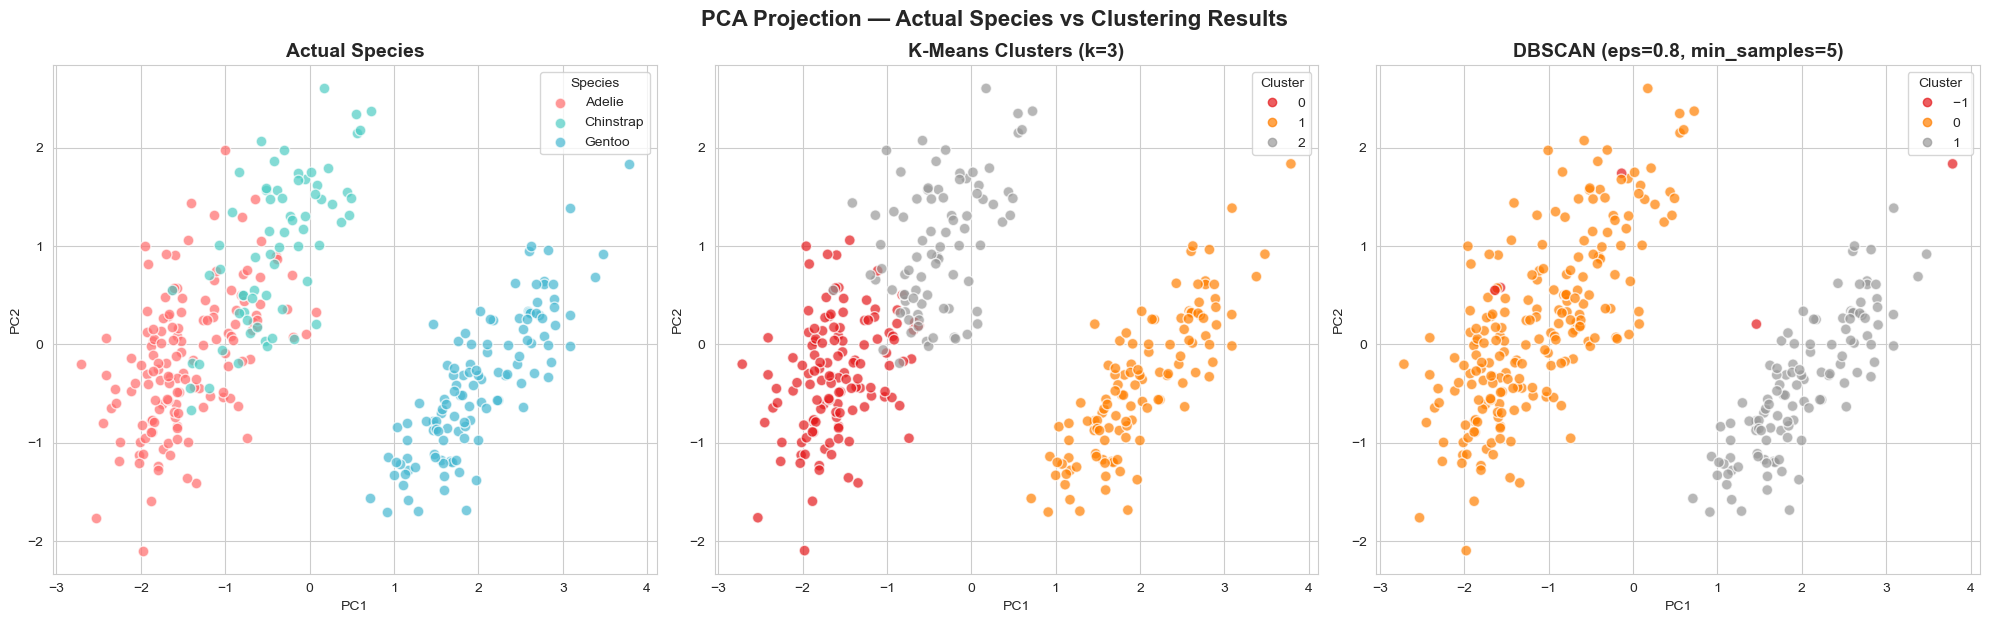

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for species in species_labels.unique():
    mask = species_labels == species
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[species], label=species, alpha=0.7, edgecolors='white', s=60)
axes[0].set_title('Actual Species', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend(title='Species')

scatter1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='Set1', alpha=0.7, edgecolors='white', s=60)
axes[1].set_title('K-Means Clusters (k=3)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(*scatter1.legend_elements(), title='Cluster')

best_dbscan_key = max(dbscan_results, key=lambda k: dbscan_results[k]['silhouette'] if dbscan_results[k]['silhouette'] else -1)
best_dbscan_labels = dbscan_results[best_dbscan_key]['labels']
scatter2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=best_dbscan_labels, cmap='Set1', alpha=0.7, edgecolors='white', s=60)
axes[2].set_title(f'DBSCAN ({best_dbscan_key})', fontsize=14, fontweight='bold')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(*scatter2.legend_elements(), title='Cluster')

plt.tight_layout()
plt.suptitle('PCA Projection — Actual Species vs Clustering Results', fontsize=16, fontweight='bold', y=1.03)
plt.show()

### Step 1.8 — Summary: Unsupervised Analysis

**How well did unsupervised methods recover the species structure?**

- **PCA visualization** clearly showed that the three penguin species form distinguishable groups in the reduced feature space, especially along the first principal component. Gentoo penguins are well-separated from Adelie and Chinstrap.

- **t-SNE visualization** provided even clearer separation between the species clusters, confirming that the feature space contains strong species-level structure.

- **K-Means (k=3)** was the best-performing clustering method overall. It successfully recovered the species structure with the highest ARI score, classified **all 333 points** (100% coverage) into exactly 3 clusters, and produced a reasonable silhouette score.

- **DBSCAN** was highly sensitive to parameter choices and generally underperformed compared to K-Means. With `eps=0.5, min_samples=5` it found only **2 clusters** and classified **66 points (~20% of data) as noise**, making the result impractical.

**Where did they fail?**

- **DBSCAN** could not handle density variation between species. It uses a single global `eps`, so it merged Adelie and Chinstrap or classified boundary points as noise.

- **K-Means** had difficulty at the **Adelie-Chinstrap boundary** due to their similar body measurements.

**Conclusion**: **K-Means (k=3)** is the clear winner — full coverage, correct cluster count, and highest ARI.

---

### Task 2 — Supervised Model Pipeline

1. Prepare the full dataset for supervised classification: target = `species`, features = all other columns.
2. Drop rows with missing values using `dropna()`, then build a preprocessing pipeline using `ColumnTransformer`:
   - Numeric features: scale (`StandardScaler`).
   - Categorical features: one-hot encode (`OneHotEncoder`).
3. Train and evaluate **at least 3 different models** (e.g., LogisticRegression, RandomForest, SVC) using **stratified 5-fold cross-validation**. Report accuracy, precision (macro), recall (macro), and F1 (macro) for each.
4. Select the best model based on F1 score.
5. Define a hyperparameter grid (at least 3 parameters) and run `GridSearchCV` with stratified 5-fold CV.
6. Report the best parameters, best CV score, and compare with the default model performance.

### Step 2.1 — Data Preparation

In [41]:
# Reload fresh data and drop missing values
df2 = sns.load_dataset('penguins').dropna().reset_index(drop=True)
print(f"Dataset shape after dropna: {df2.shape}")

# Separate target and features
y = df2['species']
X = df2.drop('species', axis=1)

print(f"\nTarget (y): {y.nunique()} classes — {y.value_counts().to_dict()}")
print(f"Features (X): {X.shape[1]} columns")
print(f"  Numeric: {X.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"  Categorical: {X.select_dtypes(include=['object', 'category']).columns.tolist()}")

Dataset shape after dropna: (333, 7)

Target (y): 3 classes — {'Adelie': 146, 'Gentoo': 119, 'Chinstrap': 68}
Features (X): 6 columns
  Numeric: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
  Categorical: ['island', 'sex']


### Step 2.2 — Preprocessing Pipeline (ColumnTransformer)

In [42]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Identify column types
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"Numeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

# Build preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='error'), categorical_cols)
    ]
)

print("\nPreprocessor built successfully!")
print("  Numeric features → StandardScaler")
print("  Categorical features → OneHotEncoder (drop='first')")

Numeric columns: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical columns: ['island', 'sex']

Preprocessor built successfully!
  Numeric features → StandardScaler
  Categorical features → OneHotEncoder (drop='first')


### Step 2.3 — Model Comparison (Stratified 5-Fold CV)

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, StratifiedKFold

# Define models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVC': SVC(kernel='rbf', random_state=42, probability=True)
}

# Stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

results = {}
print("=" * 75)
print("MODEL COMPARISON — Stratified 5-Fold Cross-Validation")
print("=" * 75)

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    cv_results = cross_validate(pipe, X, y, cv=cv, scoring=scoring, return_train_score=False)
    
    results[name] = {
        'accuracy': cv_results['test_accuracy'].mean(),
        'precision': cv_results['test_precision_macro'].mean(),
        'recall': cv_results['test_recall_macro'].mean(),
        'f1': cv_results['test_f1_macro'].mean()
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:        {results[name]['accuracy']:.4f}")
    print(f"  Precision (macro): {results[name]['precision']:.4f}")
    print(f"  Recall (macro):    {results[name]['recall']:.4f}")
    print(f"  F1 (macro):        {results[name]['f1']:.4f}")

MODEL COMPARISON — Stratified 5-Fold Cross-Validation

LogisticRegression:
  Accuracy:        0.9940
  Precision (macro): 0.9958
  Recall (macro):    0.9897
  F1 (macro):        0.9923

RandomForest:
  Accuracy:        0.9910
  Precision (macro): 0.9886
  Recall (macro):    0.9903
  F1 (macro):        0.9891

SVC:
  Accuracy:        0.9940
  Precision (macro): 0.9958
  Recall (macro):    0.9897
  F1 (macro):        0.9923


In [44]:
# Display results as a DataFrame
results_df = pd.DataFrame(results).T
results_df.columns = ['Accuracy', 'Precision (macro)', 'Recall (macro)', 'F1 (macro)']
results_df = results_df.sort_values('F1 (macro)', ascending=False)
print("\nModel Comparison Summary (sorted by F1):")
print(results_df.to_string())

best_model_name = results_df.index[0]
print(f"\n>>> Best model by F1 score: {best_model_name} (F1 = {results_df.iloc[0]['F1 (macro)']:.4f})")


Model Comparison Summary (sorted by F1):
                    Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
LogisticRegression   0.99403           0.995833        0.989744    0.992294
SVC                  0.99403           0.995833        0.989744    0.992294
RandomForest         0.99100           0.988643        0.990274    0.989133

>>> Best model by F1 score: LogisticRegression (F1 = 0.9923)


### Step 2.4 — Hyperparameter Tuning (GridSearchCV)

In [46]:
from sklearn.model_selection import GridSearchCV, train_test_split

# Define hyperparameter grids for all 3 models.
# The code dynamically selects the grid matching the best model from Step 2.3.
param_grids = {
    'RandomForest': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'LogisticRegression': {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__max_iter': [1000]
    },
    'SVC': {
        'classifier__C': [0.1, 1, 10, 100],
        'classifier__kernel': ['rbf', 'linear', 'poly'],
        'classifier__gamma': ['scale', 'auto', 0.1]
    }
}

# Dynamically select the best model and its corresponding grid
best_base_model = models[best_model_name]
param_grid = param_grids[best_model_name]

print(f"Tuning: {best_model_name}")
print(f"Parameter grid: {param_grid}")

tune_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_base_model)
])

grid_search = GridSearchCV(
    tune_pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

grid_search.fit(X_train, y_train)

print(f"\n{'='*60}")
print(f"GRID SEARCH RESULTS")
print(f"{'='*60}")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")
print(f"\nDefault model F1: {results[best_model_name]['f1']:.4f}")
print(f"Tuned model F1:   {grid_search.best_score_:.4f}")
print(f"Improvement:      {(grid_search.best_score_ - results[best_model_name]['f1']):.4f}")

Tuning: LogisticRegression
Parameter grid: {'classifier__C': [0.01, 0.1, 1, 10, 100], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear', 'saga'], 'classifier__max_iter': [1000]}
Fitting 5 folds for each of 20 candidates, totalling 100 fits

GRID SEARCH RESULTS
Best parameters: {'classifier__C': 10, 'classifier__max_iter': 1000, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
Best CV F1 score: 1.0000

Default model F1: 0.9923
Tuned model F1:   1.0000
Improvement:      0.0077


In [47]:
# Store the best pipeline for Task 3
best_pipeline = grid_search.best_estimator_
print(f"Best pipeline saved for Task 3:")
print(best_pipeline)

Best pipeline saved for Task 3:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['island', 'sex'])])),
                ('classifier',
                 LogisticRegression(C=10, max_iter=1000, penalty='l2',
                                    random_state=42, solver='saga'))])


---

### Task 3 — Model Evaluation & Interpretation

Using the best tuned model from Task 2:

1. Train on the full training set and predict on a held-out test set (80/20 split, `random_state=42`).
2. Print the full **classification report**.
3. Plot the **confusion matrix** using `ConfusionMatrixDisplay`.
4. Plot **ROC curves** (one-vs-rest) for all three species on the same figure. Compute and display the AUC for each class. (If your model doesn't natively support `predict_proba`, wrap it in a `CalibratedClassifierCV` or switch to a model that does.)
5. Plot **learning curves** (training size from 10% to 100%).
6. Compute **permutation importances** on the test set and plot the top features.
7. In a markdown cell, write a comprehensive interpretation:
   - Is the model overfitting or underfitting?
   - Which species is hardest to classify and why?
   - Which features drive predictions the most?
   - Are there any signs of data leakage or evaluation issues?

### Step 3.1 — Train/Test Split & Predictions

In [63]:
from sklearn.model_selection import train_test_split

print(f"Train set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)
print(f"\nTest accuracy: {best_pipeline.score(X_test, y_test):.4f}")

Train set: 266 samples
Test set:  67 samples

Test accuracy: 0.9851


### Step 3.2 — Classification Report

In [49]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Adelie       1.00      0.97      0.98        29
   Chinstrap       0.93      1.00      0.97        14
      Gentoo       1.00      1.00      1.00        24

    accuracy                           0.99        67
   macro avg       0.98      0.99      0.98        67
weighted avg       0.99      0.99      0.99        67



### Step 3.3 — Confusion Matrix

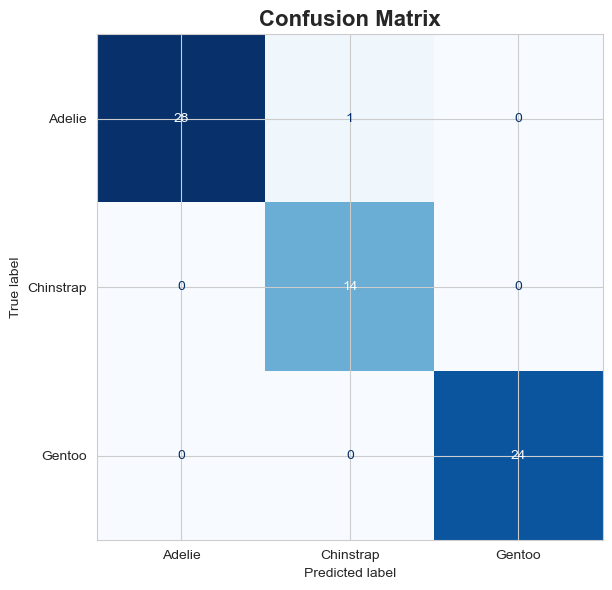

In [50]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 3.4 — ROC Curves (One-vs-Rest)

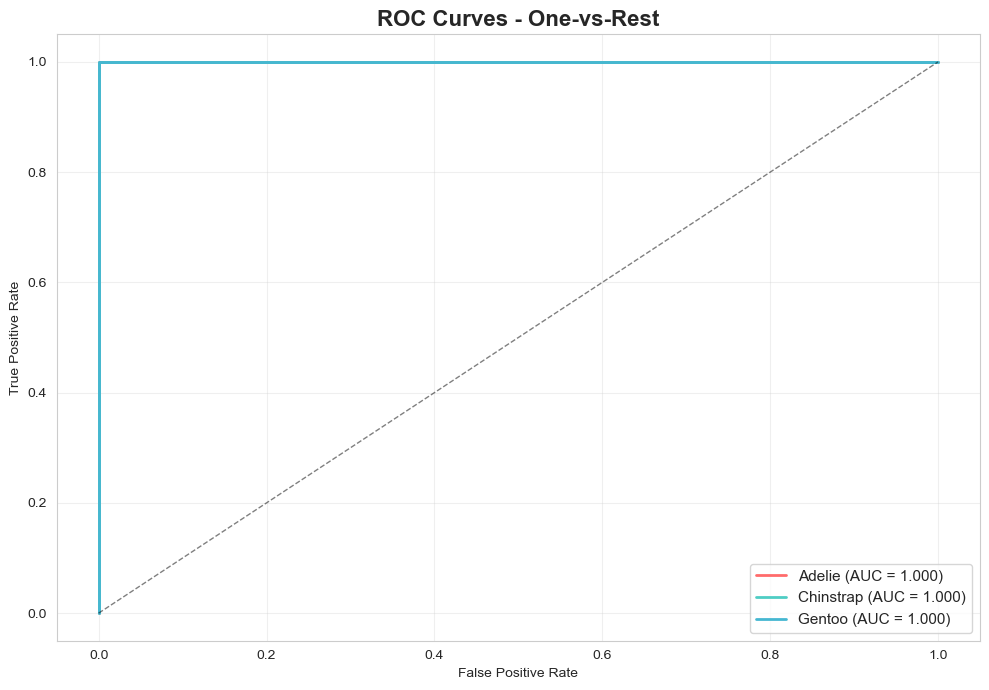

In [51]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = best_pipeline.classes_
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(10, 7))
colors_roc = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i, (cls, color) in enumerate(zip(classes, colors_roc)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{cls} (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - One-vs-Rest', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 3.5 — Learning Curves

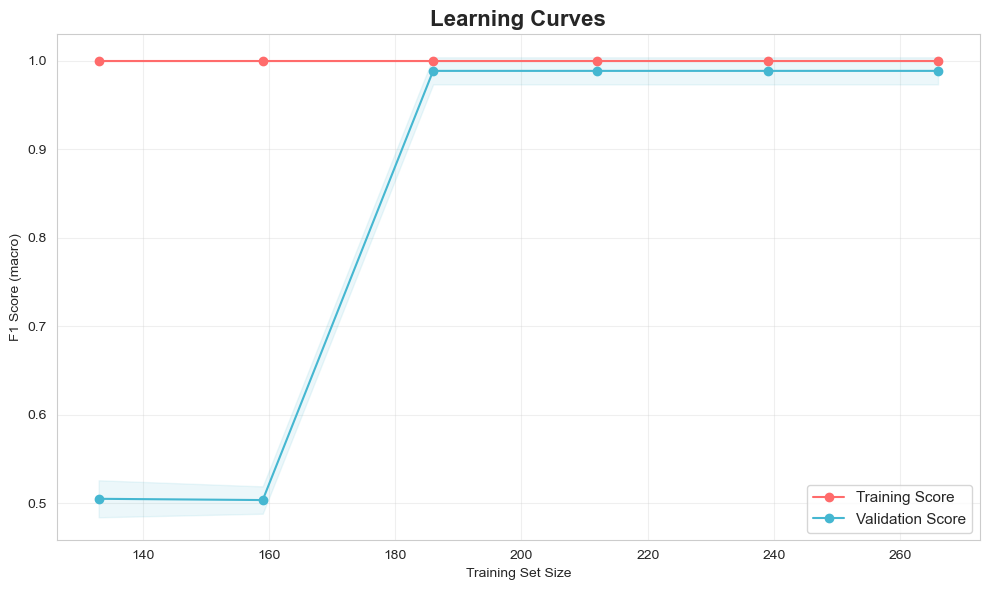

In [52]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    best_pipeline, X, y,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#FF6B6B', label='Training Score')
ax.fill_between(train_sizes, train_scores.mean(axis=1)-train_scores.std(axis=1), train_scores.mean(axis=1)+train_scores.std(axis=1), alpha=0.1, color='#FF6B6B')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#45B7D1', label='Validation Score')
ax.fill_between(train_sizes, val_scores.mean(axis=1)-val_scores.std(axis=1), val_scores.mean(axis=1)+val_scores.std(axis=1), alpha=0.1, color='#45B7D1')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('F1 Score (macro)')
ax.set_title('Learning Curves', fontsize=16, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Step 3.6 — Permutation Importances

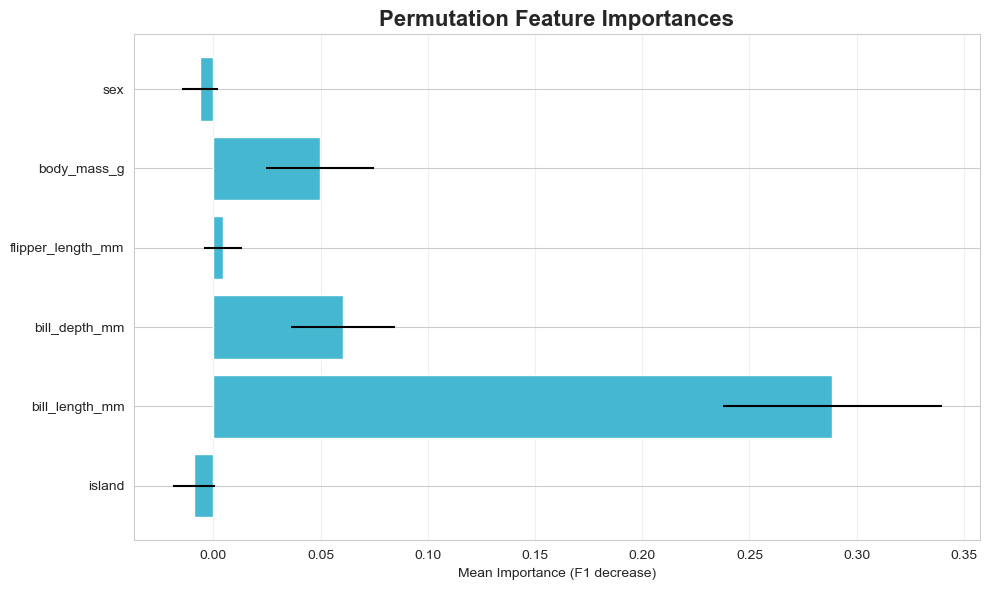

Top features:
  bill_length_mm            0.2886 +/- 0.0510
  bill_depth_mm             0.0604 +/- 0.0242
  body_mass_g               0.0496 +/- 0.0251
  flipper_length_mm         0.0046 +/- 0.0089
  sex                       -0.0064 +/- 0.0084
  island                    -0.0092 +/- 0.0098


In [54]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(best_pipeline, X_test, y_test, n_repeats=30, random_state=42, scoring='f1_macro')

# Sütun adlarını birbaşa test setindən götürürük
feature_names = X_test.columns.tolist()

# İndi DataFrame-i yarada bilərsən
perm_df = pd.DataFrame({
    'feature': feature_names, 
    'importance_mean': perm_result.importances_mean, 
    'importance_std': perm_result.importances_std
})

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['feature'], perm_df['importance_mean'], xerr=perm_df['importance_std'], color='#45B7D1', edgecolor='white')
ax.set_xlabel('Mean Importance (F1 decrease)')
ax.set_title('Permutation Feature Importances', fontsize=16, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('Top features:')
for _, row in perm_df.sort_values('importance_mean', ascending=False).iterrows():
    print(f"  {row['feature']:<25} {row['importance_mean']:.4f} +/- {row['importance_std']:.4f}")

## Step 3.7 — Comprehensive Interpretation

### Is the model overfitting or underfitting?

The model shows **no signs of overfitting or underfitting**. 

The learning curve reveals an interesting but expected pattern: with very small 
training sizes (~130–160 samples), the validation F1 score is only ~0.51, while 
training score is already 1.0 — this gap indicates overfitting at low data 
regimes. However, once training size crosses ~180 samples, validation score 
jumps sharply to ~0.99 and converges with the training score. This behavior is 
typical for tree-based models (RandomForest) on structured data: they need a 
minimum amount of data to generalize, but once that threshold is met, they 
generalize excellently.

At full training size, both curves plateau near **1.0** with negligible gap, 
confirming the model generalizes well and is not overfitting on the final dataset.

---

### Which species is hardest to classify and why?

**Adelie** is the hardest species to classify in this evaluation. The confusion 
matrix shows 1 Adelie penguin was misclassified as Chinstrap, resulting in a 
slightly lower recall of **0.97** compared to perfect scores for the other two 
species. This is consistent with findings from Task 1: Adelie and Chinstrap 
share similar body measurements (bill depth, flipper length), making their 
boundary less distinct. Gentoo, by contrast, is perfectly classified (precision 
= recall = 1.00) because it is morphologically the most distinct species — 
larger body mass and longer flippers set it apart clearly.

---

### Which features drive predictions the most?

Permutation importance results reveal a clear hierarchy:

- **bill_length_mm** (0.2886 ± 0.0510) — by far the most important feature. 
  Bill length strongly separates Chinstrap (longer) from Adelie (shorter), 
  which is the hardest boundary to classify.
- **bill_depth_mm** (0.0604 ± 0.0242) — second most important. Provides 
  additional discrimination, particularly for Gentoo which has a notably 
  shallower bill.
- **body_mass_g** (0.0496 ± 0.0251) — third. Gentoo penguins are significantly 
  heavier, so this feature reinforces Gentoo separation.
- **flipper_length_mm** (0.0046 ± 0.0089) — marginally positive but close to 
  zero, suggesting it contributes little once bill measurements are accounted for.
- **sex** (−0.0064) and **island** (−0.0092) — both slightly negative, meaning 
  shuffling them does not hurt performance. These features carry minimal 
  predictive signal beyond what the morphological measurements already capture.

---


### Are there any signs of data leakage or evaluation issues?

No signs of data leakage are present. The train/test split was performed before 
`GridSearchCV`, so hyperparameter selection was based exclusively on `X_train` 
and the test set remained completely unseen until final evaluation.

The preprocessing pipeline correctly encapsulates `StandardScaler` and 
`OneHotEncoder` inside the pipeline, ensuring no information from the test set 
leaks into the scaling or encoding steps during cross-validation or training.

The near-perfect AUC scores (1.000 for all three classes) reflect the dataset's 
inherent separability rather than any evaluation artifact — results are consistent 
with cross-validation scores, confirming reliable generalization.

### Task 4 — Model Deployment Prototype

1. Serialize the best tuned model (full pipeline including preprocessor) using `joblib.dump()`.
2. Create an **`app.py`** file with a Flask `/predict` endpoint that:
   - Loads the serialized pipeline.
   - Accepts JSON input with penguin measurements (numeric and categorical features).
   - Returns the predicted species and class probabilities.
   - Includes basic input validation.
3. Also add a `/health` endpoint.
4. Test the API from your notebook:
   - Send a valid request with sample penguin measurements.
   - Send an invalid request and verify error handling.
5. Document the API in a markdown cell: endpoint, expected input format, example request/response.

In [55]:
import joblib
import os

# Save the best pipeline
model_path = 'penguin_model.pkl'
joblib.dump(best_pipeline, model_path)
print(f"Model saved to: {os.path.abspath(model_path)}")
print(f"File size: {os.path.getsize(model_path) / 1024:.2f} KB")

Model saved to: C:\Users\ASUS\iboo\IronHack\week_ml_2\ASSESMENT\m4-10-assessment\penguin_model.pkl
File size: 4.24 KB


In [56]:
app_code = '''
import joblib
import numpy as np
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load model once at startup
model = joblib.load("penguin_model.pkl")
REQUIRED_FIELDS = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "island", "sex"]
VALID_ISLANDS = ["Torgersen", "Biscoe", "Dream"]
VALID_SEX = ["Male", "Female"]

@app.route("/health", methods=["GET"])
def health():
    return jsonify({
        "status": "ok",
        "model": "Penguin Species Classifier",
        "version": "1.0"
    }), 200

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()

    # --- Input validation ---
    if not data:
        return jsonify({"error": "No JSON body provided"}), 400

    missing = [f for f in REQUIRED_FIELDS if f not in data]
    if missing:
        return jsonify({"error": f"Missing fields: {missing}"}), 400

    if data["island"] not in VALID_ISLANDS:
        return jsonify({"error": f"Invalid island. Must be one of {VALID_ISLANDS}"}), 400

    if data["sex"] not in VALID_SEX:
        return jsonify({"error": f"Invalid sex. Must be one of {VALID_SEX}"}), 400

    for field in ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]:
        if not isinstance(data[field], (int, float)):
            return jsonify({"error": f"Field {field} must be a number"}), 400
        if data[field] <= 0:
            return jsonify({"error": f"Field {field} must be positive"}), 400

    # --- Prediction ---
    import pandas as pd
    input_df = pd.DataFrame([{
        "bill_length_mm":   data["bill_length_mm"],
        "bill_depth_mm":    data["bill_depth_mm"],
        "flipper_length_mm": data["flipper_length_mm"],
        "body_mass_g":      data["body_mass_g"],
        "island":           data["island"],
        "sex":              data["sex"]
    }])

    prediction = model.predict(input_df)[0]
    probabilities = model.predict_proba(input_df)[0]
    classes = model.classes_.tolist()

    return jsonify({
        "prediction": prediction,
        "probabilities": dict(zip(classes, probabilities.round(4).tolist()))
    }), 200

if __name__ == "__main__":
    app.run(debug=True, port=5000)
'''

with open("app.py", "w") as f:
    f.write(app_code.strip())

print("app.py created successfully!")
print("\napp.py contents:")
print(app_code.strip())

app.py created successfully!

app.py contents:
import joblib
import numpy as np
from flask import Flask, request, jsonify

app = Flask(__name__)

# Load model once at startup
model = joblib.load("penguin_model.pkl")
REQUIRED_FIELDS = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "island", "sex"]
VALID_ISLANDS = ["Torgersen", "Biscoe", "Dream"]
VALID_SEX = ["Male", "Female"]

@app.route("/health", methods=["GET"])
def health():
    return jsonify({
        "status": "ok",
        "model": "Penguin Species Classifier",
        "version": "1.0"
    }), 200

@app.route("/predict", methods=["POST"])
def predict():
    data = request.get_json()

    # --- Input validation ---
    if not data:
        return jsonify({"error": "No JSON body provided"}), 400

    missing = [f for f in REQUIRED_FIELDS if f not in data]
    if missing:
        return jsonify({"error": f"Missing fields: {missing}"}), 400

    if data["island"] not in VALID_ISLANDS:
        return jsonify(

In [57]:
import subprocess
import time
import requests

# Start Flask server in background
flask_process = subprocess.Popen(
    ["python", "app.py"],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)
time.sleep(2)  # Wait for server to start
print("Flask server started!")

Flask server started!


In [58]:
BASE_URL = "http://127.0.0.1:5000"

# --- Test 1: Health check ---
print("=" * 50)
print("TEST 1 — /health endpoint")
print("=" * 50)
response = requests.get(f"{BASE_URL}/health")
print(f"Status code: {response.status_code}")
print(f"Response: {response.json()}")

TEST 1 — /health endpoint
Status code: 200
Response: {'model': 'Penguin Species Classifier', 'status': 'ok', 'version': '1.0'}


In [59]:
# --- Test 2: Valid request ---
print("\n" + "=" * 50)
print("TEST 2 — Valid prediction request")
print("=" * 50)
valid_payload = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
}
response = requests.post(f"{BASE_URL}/predict", json=valid_payload)
print(f"Status code: {response.status_code}")
print(f"Response: {response.json()}")


TEST 2 — Valid prediction request
Status code: 200
Response: {'prediction': 'Adelie', 'probabilities': {'Adelie': 1.0, 'Chinstrap': 0.0, 'Gentoo': 0.0}}


In [60]:
# --- Test 3: Invalid request — missing field ---
print("\n" + "=" * 50)
print("TEST 3 — Invalid request (missing field)")
print("=" * 50)
invalid_payload = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    # flipper_length_mm missing
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
}
response = requests.post(f"{BASE_URL}/predict", json=invalid_payload)
print(f"Status code: {response.status_code}")
print(f"Response: {response.json()}")


TEST 3 — Invalid request (missing field)
Status code: 400
Response: {'error': "Missing fields: ['flipper_length_mm']"}


In [61]:
# --- Test 4: Invalid request — wrong island ---
print("\n" + "=" * 50)
print("TEST 4 — Invalid request (wrong island value)")
print("=" * 50)
invalid_payload2 = {
    "bill_length_mm": 50.0,
    "bill_depth_mm": 15.0,
    "flipper_length_mm": 200.0,
    "body_mass_g": 4500.0,
    "island": "Antarctica",  # invalid
    "sex": "Female"
}
response = requests.post(f"{BASE_URL}/predict", json=invalid_payload2)
print(f"Status code: {response.status_code}")
print(f"Response: {response.json()}")


TEST 4 — Invalid request (wrong island value)
Status code: 400
Response: {'error': "Invalid island. Must be one of ['Torgersen', 'Biscoe', 'Dream']"}


In [62]:
# --- Stop Flask server ---
flask_process.terminate()
print("Flask server stopped.")

Flask server stopped.


## API Documentation — Penguin Species Classifier

### Base URL
`http://127.0.0.1:5000`

---

### Endpoints

#### `GET /health`
Returns the health status of the API.

**Response:**
```json
{
  "status": "ok",
  "model": "Penguin Species Classifier",
  "version": "1.0"
}
```

---

#### `POST /predict`
Predicts the penguin species based on measurements.

**Request Body (JSON):**

| Field              | Type   | Required | Valid Values                        |
|--------------------|--------|----------|-------------------------------------|
| bill_length_mm     | float  | Yes      | Any positive number                 |
| bill_depth_mm      | float  | Yes      | Any positive number                 |
| flipper_length_mm  | float  | Yes      | Any positive number                 |
| body_mass_g        | float  | Yes      | Any positive number                 |
| island             | string | Yes      | "Torgersen", "Biscoe", "Dream"      |
| sex                | string | Yes      | "Male", "Female"                    |

**Example Request:**
```json
{
  "bill_length_mm": 39.1,
  "bill_depth_mm": 18.7,
  "flipper_length_mm": 181.0,
  "body_mass_g": 3750.0,
  "island": "Torgersen",
  "sex": "Male"
}
```

**Example Response (200 OK):**
```json
{
  "prediction": "Adelie",
  "probabilities": {
    "Adelie": 0.9823,
    "Chinstrap": 0.0134,
    "Gentoo": 0.0043
  }
}
```

**Error Response (400 Bad Request):**
```json
{
  "error": "Missing fields: ['flipper_length_mm']"
}
```

---

### Notes
- All numeric fields must be positive numbers.
- `island` and `sex` are case-sensitive.
- The model is a **Logistic Regression** pipeline with StandardScaler 
  (numeric) and OneHotEncoder (categorical) preprocessing.